In [331]:
import polars as pl
df=pl.read_parquet("../data/processed/train_features.parquet")
df.head()

pickup_hour,PULocationID,trip_count,hour_of_day,day_of_week,month,is_weekend,is_rush_hour,hour_sin,hour_cos,dow_sin,dow_cos,lag_1h,lag_24h,lag_168h,rolling_mean_3h,rolling_mean_24h,rolling_mean_168h,rolling_std_24h,rolling_std_168h
datetime[μs],i64,u32,i8,i8,i8,bool,bool,f64,f64,f64,f64,u32,u32,u32,f64,f64,f64,f64,f64
2025-01-08 00:00:00,1,0,0,3,1,false,false,0.0,1.0,0.433884,-0.900969,0,0,0,0.0,0.083333,0.196429,0.28233,0.516308
2025-01-08 01:00:00,1,0,1,3,1,false,false,0.258819,0.965926,0.433884,-0.900969,0,0,0,0.0,0.083333,0.196429,0.28233,0.516308
2025-01-08 02:00:00,1,0,2,3,1,false,false,0.5,0.866025,0.433884,-0.900969,0,0,0,0.0,0.083333,0.196429,0.28233,0.516308
2025-01-08 03:00:00,1,0,3,3,1,false,false,0.707107,0.707107,0.433884,-0.900969,0,0,0,0.0,0.083333,0.196429,0.28233,0.516308
2025-01-08 04:00:00,1,0,4,3,1,false,false,0.866025,0.5,0.433884,-0.900969,0,0,0,0.0,0.083333,0.196429,0.28233,0.516308


In [74]:
COLUMNS_TO_KEEP = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "trip_distance",
    "passenger_count",
    "fare_amount",
    "total_amount",
]


In [286]:


df = pl.read_parquet(
    "../data/processed/train.parquet"
)
df.describe()

statistic,pickup_hour,PULocationID,trip_count
str,str,f64,f64
"""count""","""1142472""",1.142472e6,1.142472e6
"""null_count""","""0""",0.0,0.0
"""mean""","""2025-04-01 11:30:00""",132.0,19.401144
"""std""",null,75.921045,56.966405
"""min""","""2025-01-01 00:00:00""",1.0,0.0
"""25%""","""2025-02-15 06:00:00""",66.0,0.0
"""50%""","""2025-04-01 12:00:00""",132.0,1.0
"""75%""","""2025-05-16 17:00:00""",198.0,5.0
"""max""","""2025-06-30 23:00:00""",263.0,992.0


In [287]:
df.shape

(1142472, 3)

In [288]:
df=df.rename({"tpep_pickup_datetime":"pickup_dt","tpep_dropoff_datetime":"dropoff_dt"})

ColumnNotFoundError: "tpep_pickup_datetime" not found

In [289]:
df.head()

pickup_hour,PULocationID,trip_count
datetime[μs],i64,u32
2025-01-01 00:00:00,1,0
2025-01-01 00:00:00,2,0
2025-01-01 00:00:00,3,0
2025-01-01 00:00:00,4,26
2025-01-01 00:00:00,5,0


In [290]:
df.describe()

statistic,pickup_hour,PULocationID,trip_count
str,str,f64,f64
"""count""","""1142472""",1.142472e6,1.142472e6
"""null_count""","""0""",0.0,0.0
"""mean""","""2025-04-01 11:30:00""",132.0,19.401144
"""std""",null,75.921045,56.966405
"""min""","""2025-01-01 00:00:00""",1.0,0.0
"""25%""","""2025-02-15 06:00:00""",66.0,0.0
"""50%""","""2025-04-01 12:00:00""",132.0,1.0
"""75%""","""2025-05-16 17:00:00""",198.0,5.0
"""max""","""2025-06-30 23:00:00""",263.0,992.0


In [291]:
df=df.drop_nulls(subset=['pickup_dt'])

ColumnNotFoundError: "pickup_dt" not found

In [292]:
df.shape

(1142472, 3)

In [293]:
df=df.filter(
    (pl.col("trip_distance")>0) &
    (pl.col("fare_amount")>0 ) &
    (pl.col("PULocationID").is_between(1,263)) &
    (pl.col("pickup_dt").dt.year()==2025)
)

ColumnNotFoundError: unable to find column "trip_distance"; valid columns: ["pickup_hour", "PULocationID", "trip_count"]

In [83]:
df.shape

(3245616, 7)

In [84]:
df=df.with_columns(
    pl.col("pickup_dt")
    .dt.truncate("1h")
    .alias("pickup_hour")
)

In [294]:
agg_df=df.group_by(["pickup_hour","PULocationID"]).len().rename({"len":"trip_count"})

In [295]:
agg_df[13500:135510]

pickup_hour,PULocationID,trip_count
datetime[μs],i64,u32
2025-03-02 09:00:00,22,1
2025-03-19 02:00:00,107,1
2025-02-03 18:00:00,259,1
2025-03-24 01:00:00,217,1
2025-02-14 12:00:00,40,1
…,…,…
2025-04-18 07:00:00,229,1
2025-05-29 01:00:00,26,1
2025-02-04 06:00:00,3,1


In [296]:
agg_df.sort(['pickup_hour']).tail()

pickup_hour,PULocationID,trip_count
datetime[μs],i64,u32
2025-06-30 23:00:00,251,1
2025-06-30 23:00:00,252,1
2025-06-30 23:00:00,87,1
2025-06-30 23:00:00,9,1
2025-06-30 23:00:00,159,1


In [297]:
agg_df.shape

(1142472, 3)

In [298]:
all_hours=pl.datetime_range(
    start=df['pickup_hour'].min().replace(minute=0,second=0,microsecond=0),
    end=df['pickup_hour'].max().replace(minute=0,second=0,microsecond=0),
    interval='1h',
    eager=True
).alias("pickup_hour")


In [299]:
all_hours

pickup_hour
datetime[μs]
2025-01-01 00:00:00
2025-01-01 01:00:00
2025-01-01 02:00:00
2025-01-01 03:00:00
2025-01-01 04:00:00
…
2025-06-30 19:00:00
2025-06-30 20:00:00
2025-06-30 21:00:00


In [300]:
all_zones=pl.Series("PULocationID",list(range(1,264)))


In [301]:
all_zones

PULocationID
i64
1
2
3
4
5
…
259
260
261


In [302]:
type(all_hours)

polars.series.series.Series

In [303]:
all_hours.shape

(4344,)

In [304]:
type(all_hours.to_frame())

polars.dataframe.frame.DataFrame

In [305]:
full_grid=all_hours.to_frame().join(all_zones.to_frame(),how='cross')

In [306]:
full_grid.shape

(1142472, 2)

In [307]:
import numpy as np

In [308]:
result=(
    full_grid
    .join(df,on=['pickup_hour',"PULocationID"],how='left')
    .with_columns(pl.col("trip_count").fill_null(0))
    .sort(['pickup_hour',"PULocationID"])
)

In [309]:
result

pickup_hour,PULocationID,trip_count
datetime[μs],i64,u32
2025-01-01 00:00:00,1,0
2025-01-01 00:00:00,2,0
2025-01-01 00:00:00,3,0
2025-01-01 00:00:00,4,26
2025-01-01 00:00:00,5,0
…,…,…
2025-06-30 23:00:00,259,0
2025-06-30 23:00:00,260,0
2025-06-30 23:00:00,261,10


In [310]:
def add_time_features(df:pl.DataFrame)->pl.DataFrame:
    time_df=df.with_columns(
        [
            pl.col("pickup_hour")
            .dt.hour()
            .alias("hour_of_day"),

           pl.col("pickup_hour")
            .dt.weekday()
            .alias("day_of_week"),

            pl.col("pickup_hour")
            .dt.month()
            .alias("month"),

            # (pl.col("pickup_hour").dt.weekday()>=5)
            # .alias("is_weekend"),

            # pl.col("pickup_hour")
            # .dt.hour()
            # .is_in([7,8,9,17,18,19])
            # .alias("is_rush_hour"),

            (
                2 * np.pi *
                pl.col("pickup_hour").dt.hour() / 24
            )
            .sin()
            .alias("hour_sin"),

            (
                2 * np.pi *
                pl.col("pickup_hour").dt.hour() / 24
            )
            .cos()
            .alias("hour_cos"),

            (
                2 * np.pi *
                pl.col("pickup_hour").dt.weekday() / 7
            )
            .sin()
            .alias("dow_sin"),

            (
                2 * np.pi *
                pl.col("pickup_hour").dt.weekday() / 7
            )
            .cos()
            .alias("dow_cos"),
        ]
    )
    return time_df

In [311]:
def add_lag_features(df:pl.DataFrame)->pl.DataFrame:
    lag_df=df.with_columns(
        [
            pl.col("trip_count")
            .shift(1)
            .over("PULocationID")
            .alias("lag_1h"),

            pl.col("trip_count")
            .shift(24)
            .over("PULocationID")
            .alias("lag_24h"),

            pl.col("trip_count")
            .shift(168)
            .over("PULocationID")
            .alias("lag_168h"),
        ]
    )
    return lag_df

In [312]:
def add_rolling_features(df:pl.DataFrame)->pl.DataFrame:
    rolling_df=df.with_columns(
        [
            pl.col("trip_count")
            .shift(1)
            .rolling_mean(window_size=3)
            .over("PULocationID")
            .alias("rolling_mean_3h"),

            pl.col("trip_count")
            .shift(1)
            .rolling_mean(window_size=24)
            .over("PULocationID")
            .alias("rolling_mean_24h"),

            pl.col("trip_count")
            .shift(1)
            .rolling_mean(168)
            .over("PULocationID")
            .alias("rolling_mean_168h"),

            pl.col("trip_count")
            .shift(1)
            .rolling_std(window_size=24)
            .over("PULocationID")
            .alias("rolling_std_24h"),

            pl.col("trip_count")
            .shift(1)
            .rolling_std(168)
            .over("PULocationID")
            .alias("rolling_std_168h")
        ]
    )
    return rolling_df

In [313]:

def drop_nulls(df:pl.DataFrame)->pl.DataFrame:
    df=df.drop_nulls(subset=[
        'lag_1h',
        'lag_24h',
        'lag_168h',
        'rolling_mean_3h',
        'rolling_mean_24h',
        'rolling_mean_168h',
        'rolling_std_24h,'
        'rolling_std_168h'
        ])
    return df

In [314]:
TARGET_COL = "trip_count"
LOCATION_COL = "PULocationID"
TIME_COL = "pickup_hour"

In [315]:
def build_features(df:pl.DataFrame)->pl.DataFrame:
    df=df.sort([LOCATION_COL,TIME_COL])
    df=add_time_features(df)
    df=add_lag_features(df)
    df=add_rolling_features(df)
    df=drop_nulls(df)
    return df

In [316]:
featured_df=build_features(result)

ColumnNotFoundError: "rolling_std_24h,rolling_std_168h" not found

In [317]:
featured_df

pickup_hour,PULocationID,trip_count,hour_of_day,day_of_week,month,hour_sin,hour_cos,dow_sin,dow_cos,lag_1h,lag_24h,lag_168h,rolling_mean_3h,rolling_mean_24h,rolling_mean_168h,rolling_std_24h,rolling_std_168h
datetime[μs],i64,u32,i8,i8,i8,f64,f64,f64,f64,u32,u32,u32,f64,f64,f64,f64,f64
2025-01-08 00:00:00,1,0,0,3,1,0.0,1.0,0.433884,-0.900969,0,0,0,0.0,0.083333,0.196429,0.28233,0.516308
2025-01-08 01:00:00,1,0,1,3,1,0.258819,0.965926,0.433884,-0.900969,0,0,0,0.0,0.083333,0.196429,0.28233,0.516308
2025-01-08 02:00:00,1,0,2,3,1,0.5,0.866025,0.433884,-0.900969,0,0,0,0.0,0.083333,0.196429,0.28233,0.516308
2025-01-08 03:00:00,1,0,3,3,1,0.707107,0.707107,0.433884,-0.900969,0,0,0,0.0,0.083333,0.196429,0.28233,0.516308
2025-01-08 04:00:00,1,0,4,3,1,0.866025,0.5,0.433884,-0.900969,0,0,0,0.0,0.083333,0.196429,0.28233,0.516308
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-06-30 19:00:00,263,104,19,1,6,-0.965926,0.258819,0.781831,0.62349,118,90,115,98.666667,73.625,91.291667,40.529981,47.00495
2025-06-30 20:00:00,263,79,20,1,6,-0.866025,0.5,0.781831,0.62349,104,76,106,103.333333,74.208333,91.22619,40.875186,46.979382
2025-06-30 21:00:00,263,76,21,1,6,-0.707107,0.707107,0.781831,0.62349,79,81,105,100.333333,74.333333,91.065476,40.885489,46.974721


In [318]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [319]:
import polars as pl

In [320]:
df=pl.read_parquet("../data/processed/train_features.parquet")

In [321]:
df

pickup_hour,PULocationID,trip_count,hour_of_day,day_of_week,month,is_weekend,is_rush_hour,lag_1h,lag_24h,lag_168h,rolling_mean_3h,rolling_mean_24h
datetime[μs],i64,u32,i8,i8,i8,bool,bool,u32,u32,u32,f64,f64
2025-01-08 00:00:00,1,0,0,3,1,false,false,0,0,0,0.0,0.083333
2025-01-08 01:00:00,1,0,1,3,1,false,false,0,0,0,0.0,0.083333
2025-01-08 02:00:00,1,0,2,3,1,false,false,0,0,0,0.0,0.083333
2025-01-08 03:00:00,1,0,3,3,1,false,false,0,0,0,0.0,0.083333
2025-01-08 04:00:00,1,0,4,3,1,false,false,0,0,0,0.0,0.083333
…,…,…,…,…,…,…,…,…,…,…,…,…
2025-06-30 19:00:00,263,104,19,1,6,false,true,118,90,115,98.666667,73.625
2025-06-30 20:00:00,263,79,20,1,6,false,false,104,76,106,103.333333,74.208333
2025-06-30 21:00:00,263,76,21,1,6,false,false,79,81,105,100.333333,74.333333


In [322]:
VALIDATION_SPLIT_DATE = "2023-05-01" 

In [323]:
import mlflow
import mlflow.xgboost
import xgboost as xgb
import polars as pl
import numpy as np
from pathlib import Path

MLFLOW_TRACKING_URI = "http://localhost:5000"
MLFLOW_EXPERIMENT = "ride-demand-forecast"
RANDOM_SEED = 42
XGB_PARAMS = {
    'objective':"reg:squarederror",
    "n_estimators": 2000,
    "learning_rate": 0.03,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": RANDOM_SEED,
}
from datetime import datetime

VALIDATION_SPLIT_DATE = datetime(
    2025, 6, 1, 0, 0, 0
)
TARGET_COL = "trip_count"

In [1]:
import mlflow

print(mlflow.get_tracking_uri())

sqlite:///C:/Users/chinn/OneDrive/Desktop/projects/Ride-Demand-Prediction-System/Ride-Demand-Prediction-System/notebooks/mlflow.db


In [7]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

model = client.get_model_version(
    name="ride_demand_xgboost",
    version="1"   # replace with your version
)

print(model.source)

models:/m-a60a21db962343c8af14d8605242ada6


In [8]:
from mlflow import MlflowClient

client = MlflowClient()

model = client.get_logged_model(
    "m-a60a21db962343c8af14d8605242ada6"
)

print(model)

LoggedModel(artifact_location='mlflow-artifacts:/1/models/m-a60a21db962343c8af14d8605242ada6/artifacts', creation_timestamp=1780566768799, experiment_id='1', last_updated_timestamp=1780566787717, model_id='m-a60a21db962343c8af14d8605242ada6', model_type='', model_uri='models:/m-a60a21db962343c8af14d8605242ada6', name='model', source_run_id='8e62a55d248c4e95be683e41ff8e4adc', status=<LoggedModelStatus.READY: 'READY'>, status_message='')


In [13]:
model = mlflow.xgboost.load_model(
    "models:/m-a60a21db962343c8af14d8605242ada6"
)

2026/06/04 18:06:58 INFO mlflow.store.artifact.artifact_repo: No artifacts found to download at http://localhost:5000/api/2.0/mlflow-artifacts/artifacts/1/models/m-a60a21db962343c8af14d8605242ada6/artifacts. Returning destination path.


MlflowException: Could not find a registered artifact repository for: c:\Users\chinn\AppData\Local\Temp\tmpql3kqwmj. Currently registered schemes are: ['', 'file', 's3', 'r2', 'b2', 'gs', 'wasbs', 'ftp', 'sftp', 'dbfs', 'hdfs', 'viewfs', 'runs', 'models', 'http', 'https', 'mlflow-artifacts', 'abfss']

In [14]:
import mlflow

print(mlflow.get_tracking_uri())

http://localhost:5000


In [11]:
from mlflow import MlflowClient

client = MlflowClient()

model = client.get_logged_model(
    "m-a60a21db962343c8af14d8605242ada6"
)

print(model.artifact_location)
print(model.source_run_id)

mlflow-artifacts:/1/models/m-a60a21db962343c8af14d8605242ada6/artifacts
8e62a55d248c4e95be683e41ff8e4adc


In [12]:
from mlflow import MlflowClient

client = MlflowClient()

model = client.get_logged_model(
    "m-a60a21db962343c8af14d8605242ada6"
)

print(model.artifact_location)
print(model.source_run_id)

mlflow-artifacts:/1/models/m-a60a21db962343c8af14d8605242ada6/artifacts
8e62a55d248c4e95be683e41ff8e4adc


In [2]:
from pathlib import Path

db = Path(
    r"C:\Users\chinn\OneDrive\Desktop\projects\Ride-Demand-Prediction-System\Ride-Demand-Prediction-System\notebooks\mlflow.db"
)


print(db.exists())

False


In [22]:
import mlflow

mlflow.set_tracking_uri(
    "http://localhost:5000"
)

model = mlflow.pyfunc.load_model(
    "models:/ride_demand_xgb/latest"
)

2026/06/04 18:30:00 INFO mlflow.store.artifact.artifact_repo: No artifacts found to download at http://localhost:5000/api/2.0/mlflow-artifacts/artifacts/1/models/m-d62d2fc665654995b603770c75a11512/artifacts. Returning destination path.


MlflowException: Could not find a registered artifact repository for: c:. Currently registered schemes are: ['', 'file', 's3', 'r2', 'b2', 'gs', 'wasbs', 'ftp', 'sftp', 'dbfs', 'hdfs', 'viewfs', 'runs', 'models', 'http', 'https', 'mlflow-artifacts', 'abfss']

In [19]:
from mlflow import MlflowClient

client = MlflowClient()

for mv in client.search_model_versions(
    "name='ride_demand_xgboost'"
):
    print(mv.version)

4
3
2
1


In [21]:
import mlflow

mlflow.set_tracking_uri(
    "http://localhost:5000"
)

model = mlflow.xgboost.load_model(
    "models:/ride_demand_xgboost/latest"
)

In [3]:
from mlflow.tracking import MlflowClient

client = MlflowClient(tracking_uri="http://localhost:5000")

for exp in client.search_experiments():
    print(exp.experiment_id, exp.name)

0 Default


In [16]:
from mlflow import MlflowClient

client = MlflowClient()

for mv in client.search_model_versions(
    "name='ride_demand_xgboost'"
):
    print("Version:", mv.version)
    print("Source:", mv.source)
    print("Run ID:", mv.run_id)

Version: 3
Source: models:/m-3944445c40d64cec954081520adbe053
Run ID: 65ec073e6b6d46e78907d78e8b86cac9
Version: 2
Source: models:/m-670eefe26eb44c959bda12c97cd8d7ee
Run ID: d25bb703267646d18c29033f63ff6228
Version: 1
Source: models:/m-a60a21db962343c8af14d8605242ada6
Run ID: 8e62a55d248c4e95be683e41ff8e4adc


In [17]:
from mlflow import MlflowClient

client = MlflowClient()

run = client.get_run(
    "8e62a55d248c4e95be683e41ff8e4adc"
)

print(run.info.artifact_uri)

mlflow-artifacts:/1/8e62a55d248c4e95be683e41ff8e4adc/artifacts


In [18]:
model = mlflow.pyfunc.load_model(
    "models:/ride_demand_xgboost/3"
)

2026/06/04 18:22:26 INFO mlflow.store.artifact.artifact_repo: No artifacts found to download at http://localhost:5000/api/2.0/mlflow-artifacts/artifacts/1/models/m-3944445c40d64cec954081520adbe053/artifacts. Returning destination path.


MlflowException: Could not find a registered artifact repository for: c:. Currently registered schemes are: ['', 'file', 's3', 'r2', 'b2', 'gs', 'wasbs', 'ftp', 'sftp', 'dbfs', 'hdfs', 'viewfs', 'runs', 'models', 'http', 'https', 'mlflow-artifacts', 'abfss']

In [4]:
import sqlite3

conn = sqlite3.connect("../mlflow.db")

cursor = conn.cursor()

cursor.execute(
    "SELECT experiment_id, name FROM experiments"
)

print(cursor.fetchall())

[(0, 'Default'), (1, 'ride-demand-forecast')]


In [324]:
# src/features/schema.py
FEATURE_SCHEMA = {
    "hour_of_day":       {"dtype": "int8",    "min": 0,   "max": 23},
    "day_of_week":       {"dtype": "int8",    "min": 0,   "max": 6},
    "month":             {"dtype": "int8",    "min": 1,   "max": 12},

    # "is_weekend":        {"dtype": "bool",    "min": 0,   "max": 1},
    # "is_rush_hour":      {"dtype": "bool",    "min": 0,   "max": 1},

    "hour_sin":          {"dtype": "float64", "min": -1,  "max": 1},
    "hour_cos":          {"dtype": "float64", "min": -1,  "max": 1},

    "dow_sin":           {"dtype": "float64", "min": -1,  "max": 1},
    "dow_cos":           {"dtype": "float64", "min": -1,  "max": 1},

    "lag_1h":            {"dtype": "float64", "min": 0,   "max": None},
    "lag_24h":           {"dtype": "float64", "min": 0,   "max": None},
    "lag_168h":          {"dtype": "float64", "min": 0,   "max": None},

    "rolling_mean_3h":   {"dtype": "float64", "min": 0,   "max": None},
    "rolling_mean_24h":  {"dtype": "float64", "min": 0,   "max": None},
    "rolling_mean_168h": {"dtype": "float64", "min": 0,   "max": None},

    "rolling_std_24h":   {"dtype": "float64", "min": 0,   "max": None},
    "rolling_std_168h":  {"dtype": "float64", "min": 0,   "max": None},

    # "zone_avg_demand":   {"dtype": "float64", "min": 0,   "max": None},
    "zone_hour_avg":     {"dtype": "float64", "min": 0,   "max": None},
    "PULocationID":      {"dtype": "category", "min": 1,  "max": 263},
}
FEATURE_COLUMNS = list(FEATURE_SCHEMA.keys())


In [325]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_absolute_percentage_error

def compute_metrics(y_true,y_pred)->dict:
    rmse=root_mean_squared_error(y_true=y_true,y_pred=y_pred)
    mae=mean_absolute_error(y_true=y_true,y_pred=y_pred)
    mask=y_true!=0
    mape=mean_absolute_percentage_error(y_true=y_true[mask],y_pred=y_pred[mask])

    return {"rmse":rmse,"mae":mae,"mape":mape}

from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from datetime import timedelta


def plot_predictions(
    val_df: pl.DataFrame,
    y_pred: np.ndarray,
    zone_id: int,
    title: str,
    save_path: Path,
) -> Path:

    pred_df = val_df.with_columns(
        pl.Series("prediction", y_pred)
    )

    zone_df = (
        pred_df
        .filter(pl.col("PULocationID") == zone_id)
        .sort("pickup_hour")
        .head(168)
    )

    if zone_df.is_empty():
        raise ValueError(
            f"No validation data found for zone {zone_id}"
        )

    hours = zone_df["pickup_hour"].to_list()
    y_true = zone_df["trip_count"].to_numpy()
    y_pred_zone = zone_df["prediction"].to_numpy()

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(
        hours,
        y_true,
        label="Actual",
        linewidth=2,
    )

    ax.plot(
        hours,
        y_pred_zone,
        label="Predicted",
        linewidth=2,
        linestyle="--",
    )

    rush_hours = {7, 8, 9, 17, 18, 19}

    for dt in hours:
        if dt.hour in rush_hours:
            ax.axvspan(
                dt,
                dt + timedelta(hours=1),
                alpha=0.08,
            )

    ax.set_title(
        f"{title} | Zone {zone_id}"
    )

    ax.set_xlabel("Pickup Hour")
    ax.set_ylabel("Trip Count")

    ax.legend()
    ax.grid(alpha=0.3)

    fig.autofmt_xdate()
    fig.tight_layout()

    save_path = Path(save_path)

    save_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.close(fig)

    return save_path



[0]	validation_0-rmse:55.84616
[100]	validation_0-rmse:10.42096
[200]	validation_0-rmse:9.72319
[300]	validation_0-rmse:9.57473
[400]	validation_0-rmse:9.47355
[500]	validation_0-rmse:9.40097
[600]	validation_0-rmse:9.34159
[700]	validation_0-rmse:9.29609
[800]	validation_0-rmse:9.26569
[900]	validation_0-rmse:9.23699
[1000]	validation_0-rmse:9.21877
[1100]	validation_0-rmse:9.19720
[1200]	validation_0-rmse:9.18065
[1300]	validation_0-rmse:9.16363
[1400]	validation_0-rmse:9.14886
[1500]	validation_0-rmse:9.14290
[1600]	validation_0-rmse:9.13129
[1694]	validation_0-rmse:9.12858


2026/06/03 20:49:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'ride_demand_xgb' already exists. Creating a new version of this model...
2026/06/03 20:49:36 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: ride_demand_xgb, version 27
Created version '27' of model 'ride_demand_xgb'.


Axes(0.125,0.11;0.775x0.77)
🏃 View run receptive-steed-75 at: http://localhost:5000/#/experiments/1/runs/8d62ba50e6cd4b5887f72869e96f7674
🧪 View experiment at: http://localhost:5000/#/experiments/1


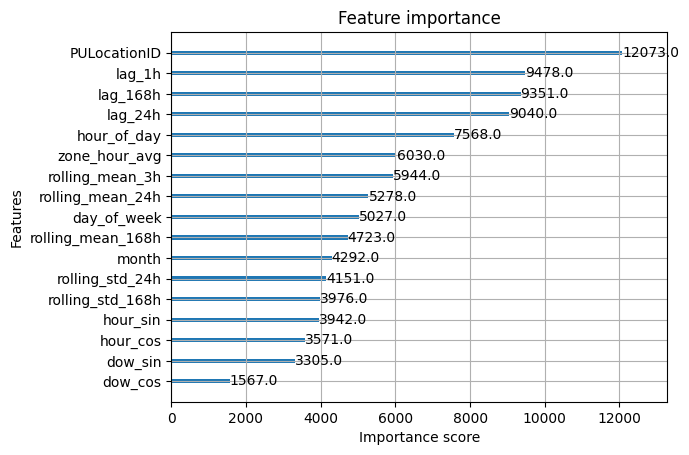

In [326]:
def load_training_data(df=pl.DataFrame)->tuple:
    # df=pl.read_parquet('../data/processed/train_features.parquet')

    train_df=df.filter(pl.col("pickup_hour")<VALIDATION_SPLIT_DATE)
    val_df=df.filter(pl.col("pickup_hour")>=VALIDATION_SPLIT_DATE)

    zone_hour_avg = (
        train_df
        .group_by(
            ["PULocationID", "hour_of_day"]
        )
        .agg(
            pl.mean("trip_count")
            .alias("zone_hour_avg")
        )
    )

    train_df = train_df.join(
        zone_hour_avg,
        on=["PULocationID", "hour_of_day"],
        how="left"
    )
    val_df = val_df.join(
        zone_hour_avg,
        on=["PULocationID", "hour_of_day"],
        how="left"
    )
  

    X_train=train_df.select(FEATURE_COLUMNS).to_pandas()
    y_train=train_df[TARGET_COL].to_pandas()
    X_val=val_df.select(FEATURE_COLUMNS).to_pandas()
    y_val=val_df[TARGET_COL].to_pandas()

    X_train['PULocationID']=X_train['PULocationID'].astype("category")
    X_val["PULocationID"]=X_val["PULocationID"].astype("category")

    return X_train,y_train,X_val,y_val,val_df


mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

X_train,y_train,X_val,y_val,val_df=load_training_data(featured_df)

with mlflow.start_run():
    mlflow.set_tags({
        "model":"XGBoost",
        "version":"0.1",
        "name":"ride_analysis_xgboost"
    })

    mlflow.log_params(
        XGB_PARAMS
    )

    model=xgb.XGBRegressor(
        **XGB_PARAMS,
        enable_categorical=True,
        tree_method='hist',
        early_stopping_rounds=50
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=100,
    )
    train_pred = model.predict(X_train)
    train_metrics = compute_metrics(y_train, train_pred)

    val_pred = model.predict(X_val)
    val_metrics = compute_metrics(y_val, val_pred)

    
    save_path=plot_predictions(val_df,val_pred,zone_id=200,save_path=Path("../artifacts/val_forecast.png"),title="validation actual vs prediction plot")
    train_metrics = {
        f"train_{k}": v
        for k, v in train_metrics.items()
    }

    val_metrics = {
        f"val_{k}": v
        for k, v in val_metrics.items()
    }
    lag1_rmse=root_mean_squared_error(
        y_val,
        X_val["lag_1h"]
    )

    lag24_rmse=root_mean_squared_error(
            y_val,
            X_val["lag_24h"]
        )
    lag168_rmse=root_mean_squared_error(
            y_val,
            X_val["lag_168h"]
        )
    
    baseline_metrics = {
    "baseline_lag1_rmse": lag1_rmse,
    "baseline_lag24_rmse": lag24_rmse,
        "baseline_lag168_rmse": lag168_rmse,
    }

    mlflow.log_metrics(baseline_metrics)
    mlflow.log_metrics(train_metrics)
    mlflow.log_metrics(val_metrics)

    mlflow.log_artifact(str(save_path))

    mlflow.xgboost.log_model(
        model,
        artifact_path="model",
            registered_model_name="ride_demand_xgb"
    )

    print(xgb.plot_importance(model))



In [282]:
from sklearn.metrics import root_mean_squared_error
mlflow.end_run()


🏃 View run trusting-mare-819 at: http://localhost:5000/#/experiments/1/runs/f21ceb733ed84edfad1ff30631abbdea
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [ ]:
baseline_metrics = {
    "baseline_lag1_rmse": lag1_rmse,
    "baseline_lag24_rmse": lag24_rmse,
    "baseline_lag168_rmse": lag168_rmse,
}

mlflow.log_metrics(baseline_metrics)